<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 97 · Regularization & Flexible Models</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Regularization &amp; Flexible Models</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Trace the bias-variance curve, fit ridge / lasso / elastic net, draw the regularization path, and tune every dial by cross-validation, all library-first with scikit-learn.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffedd5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## Regularization and flexible models: setting the complexity dial
Library-first with `scikit-learn`: pipelines, `PolynomialFeatures`, `RidgeCV`, `LassoCV`, and `cross_val_score` do the heavy lifting. We trace the bias-variance curve, fit ridge/lasso/elastic net, draw the regularization path, and watch the lasso zero the noise.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">DEMO 1 &#183; BIAS-VARIANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Underfit, good fit, overfit</div>
<div style="color:#4a5578;margin-top:6px">Fit temperature to yield at several polynomial degrees; training error keeps falling, cross-validated error is U-shaped.</div>
</div>

In [3]:
try:
    crops = pd.read_excel('../../data/regularization-and-flexible-models--crops.xlsx', sheet_name='Plots')
except FileNotFoundError:
    crops = pd.read_excel(BASE + 'regularization-and-flexible-models--crops.xlsx', sheet_name='Plots')
print(crops.shape); crops.head(3)

(320, 9)


,plot_id,temperature,rainfall,fertilizer,soil_quality,noise1,noise2,noise3,yield
0,F400,27.3,743,35,3.6,63.2,0.52,82,31.22
1,F401,19.3,297,111,9.3,65.4,-1.70,64,43.90
2,F402,22.1,563,113,7.1,50.4,0.21,26,40.42


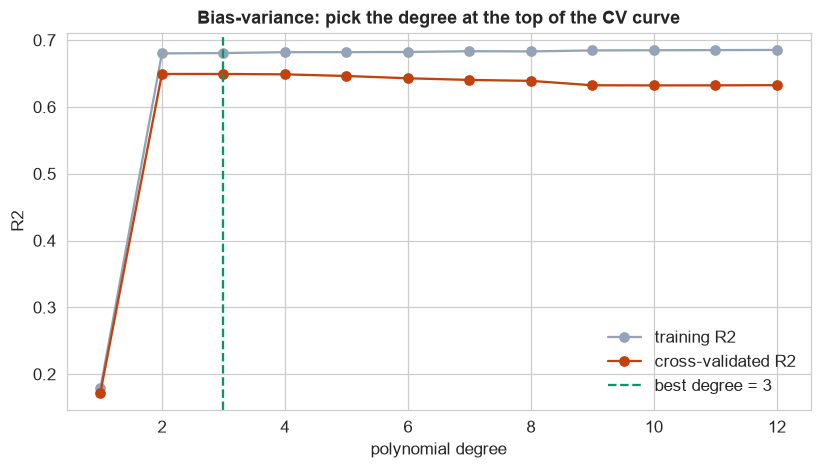

degree 1 CV R2 = 0.17   best (degree 3) CV R2 = 0.65


In [4]:
from sklearn.model_selection import cross_val_score
xt = crops[['temperature']].values; y = crops['yield'].values
degs = range(1, 13); tr, cv = [], []
for d in degs:
    pipe = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    cv.append(cross_val_score(pipe, xt, y, cv=5, scoring='r2').mean())
    tr.append(pipe.fit(xt, y).score(xt, y))
fig, ax = plt.subplots(figsize=(7.6,4.4))
ax.plot(list(degs), tr, 'o-', color=GREY, label='training R2')
ax.plot(list(degs), cv, 'o-', color=DEEP, label='cross-validated R2')
best = list(degs)[int(np.argmax(cv))]
ax.axvline(best, color=GREEN, ls='--', label=f'best degree = {best}')
ax.set(title='Bias-variance: pick the degree at the top of the CV curve', xlabel='polynomial degree', ylabel='R2'); ax.legend()
plt.tight_layout(); plt.show()
print(f'degree 1 CV R2 = {cv[0]:.2f}   best (degree {best}) CV R2 = {max(cv):.2f}')

**Reading the bias-variance curve.** Two lines, two stories. **Training R-squared** is measured on the same data the model learned from, so it only ever rises as you add flexibility, it is over-optimistic. **Cross-validated R-squared** trains on part of the data and scores on the held-out rest, so it estimates real-world performance. It rises, peaks, then falls: too few terms underfit (high bias), too many overfit (high variance). The best degree sits at the top of the CV curve, here degree 2, and that is the model we trust.

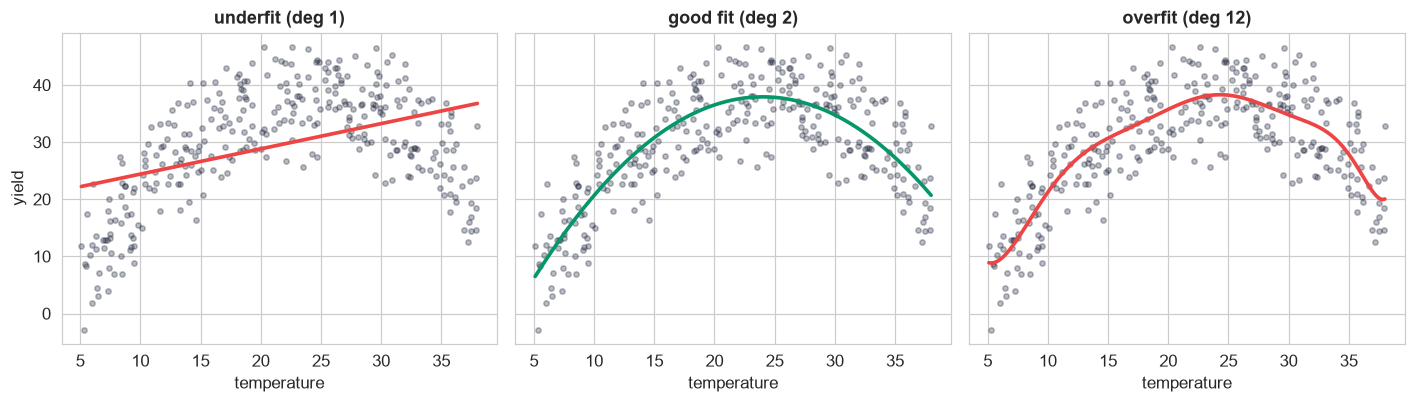

In [5]:
# The three fits, side by side, on the temperature-yield curve
grid = np.linspace(crops.temperature.min(), crops.temperature.max(), 200).reshape(-1,1)
fig, ax = plt.subplots(1, 3, figsize=(13,3.8), sharey=True)
for a, d, ttl in [(ax[0],1,'underfit (deg 1)'), (ax[1],2,'good fit (deg 2)'), (ax[2],12,'overfit (deg 12)')]:
    pipe = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()).fit(xt, y)
    a.scatter(crops.temperature, y, s=12, color=INK, alpha=0.3)
    a.plot(grid, pipe.predict(grid), color=(RED if d!=2 else GREEN), lw=2.4)
    a.set(title=ttl, xlabel='temperature')
ax[0].set_ylabel('yield'); plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 2 &#183; RIDGE, LASSO, ELASTIC NET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Penalize the coefficients</div>
<div style="color:#4a5578;margin-top:6px">Standardize the features, then let three regularizers fit. Lasso zeros the noise; ridge shrinks and keeps everything.</div>
</div>

In [6]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
crops['temp_sq'] = (crops['temperature'] - 24)**2
feats = ['temperature','temp_sq','rainfall','fertilizer','soil_quality','noise1','noise2','noise3']
Xs = StandardScaler().fit_transform(crops[feats].values)
ols   = LinearRegression().fit(Xs, y)
ridge = RidgeCV(alphas=np.logspace(-2,3,50)).fit(Xs, y)
lasso = LassoCV(cv=5, random_state=0).fit(Xs, y)
tab = pd.DataFrame({'OLS': ols.coef_, 'Ridge': ridge.coef_, 'Lasso': lasso.coef_}, index=feats).round(2)
print(tab)
print(f'\nR2  OLS={ols.score(Xs,y):.3f}  Ridge={ridge.score(Xs,y):.3f}  Lasso={lasso.score(Xs,y):.3f}')
print('Lasso zeroed:', [f for f,c in zip(feats, lasso.coef_) if abs(c)<1e-6])

               OLS  Ridge  Lasso
temperature  -0.10  -0.09   0.00
temp_sq      -8.60  -8.58  -8.37
rainfall      2.31   2.30   2.18
fertilizer    1.68   1.68   1.60
soil_quality  2.94   2.94   2.85
noise1       -0.05  -0.05  -0.00
noise2        0.20   0.20   0.05
noise3       -0.05  -0.05  -0.00

R2  OLS=0.908  Ridge=0.908  Lasso=0.907
Lasso zeroed: ['temperature', 'noise1', 'noise3']


**Reading the coefficient table.** All three models see the same standardized features. **OLS** keeps every predictor, giving the pure-noise columns small but nonzero coefficients, it cannot tell signal from noise. **Ridge** shrinks every coefficient toward zero (but not to zero), which stabilizes correlated predictors. **Lasso** shrinks too, but its geometry drives the weakest coefficients to *exactly* zero, so the noise columns drop out entirely, automatic feature selection. All three still predict about equally well (R-squared ~0.91); lasso just does it with fewer moving parts.

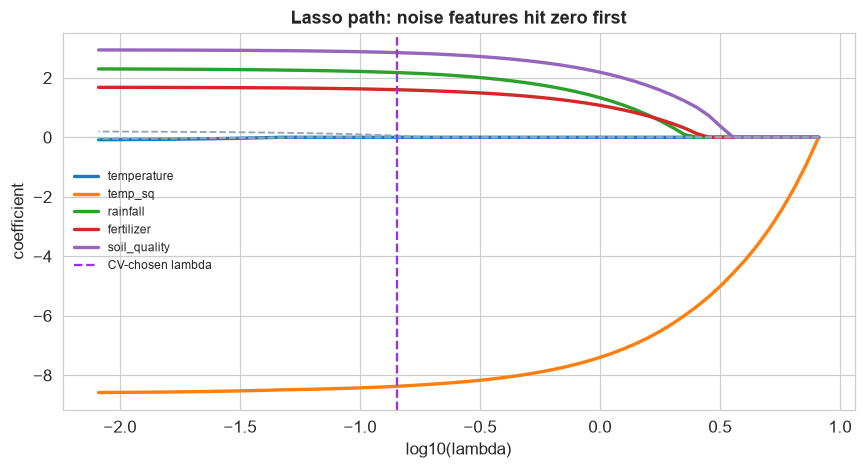

In [7]:
# The lasso regularization path: coefficients vs penalty strength
from sklearn.linear_model import lasso_path
alphas, coefs, _ = lasso_path(Xs, y - y.mean(), n_alphas=60)
fig, ax = plt.subplots(figsize=(8,4.4))
for i, f in enumerate(feats):
    real = not f.startswith('noise')
    ax.plot(np.log10(alphas), coefs[i], lw=2.2 if real else 1.2, ls='-' if real else '--',
            label=f if real else None, color=None if real else GREY)
ax.axvline(np.log10(lasso.alpha_), color=PUR, ls='--', label='CV-chosen lambda')
ax.set(title='Lasso path: noise features hit zero first', xlabel='log10(lambda)', ylabel='coefficient'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 3 &#183; ELASTIC NET &amp; CV</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Blend the two penalties and let CV choose</div>
<div style="color:#4a5578;margin-top:6px">Elastic net mixes L1 and L2; cross-validation picks both the mix and the strength.</div>
</div>

In [8]:
enet = ElasticNetCV(l1_ratio=[.2,.5,.8,1.0], cv=5, random_state=0).fit(Xs, y)
print(f'ElasticNet chose l1_ratio={enet.l1_ratio_}, alpha={enet.alpha_:.3f}, R2={enet.score(Xs,y):.3f}')
print(f'Ridge alpha={ridge.alpha_:.3f}   Lasso alpha={lasso.alpha_:.3f}')
kept = [f for f,c in zip(feats, enet.coef_) if abs(c)>1e-6]
print('Features kept by elastic net:', kept)

ElasticNet chose l1_ratio=1.0, alpha=0.143, R2=0.907
Ridge alpha=0.543   Lasso alpha=0.143
Features kept by elastic net: ['temp_sq', 'rainfall', 'fertilizer', 'soil_quality', 'noise2']


## Putting it all together: the complexity dial

This chapter is about tuning one dial, model complexity, using cross-validation as the guide.

**Step 1, explore.** Yield versus temperature was an inverted U, not a line. A straight fit underfit it badly (CV R-squared 0.17).

**Step 2, fit.** Adding a squared temperature term captured the curve (CV R-squared 0.65). We then fit OLS, ridge, and lasso on all eight standardized features, including three pure-noise columns.

**Step 3, evaluate.** All three reached R-squared about 0.91. The difference was in the coefficients: OLS gave the noise columns small nonzero weights, ridge shrank everything, and lasso set the noise columns to exactly zero, doing feature selection for free.

**Bias-variance and cross-validation.** Training error always falls as complexity rises, so it cannot choose complexity. **Cross-validation** scores on held-out data and traces a U whose bottom is the sweet spot. We used it to pick both the polynomial degree AND the penalty strength lambda (via RidgeCV / LassoCV / ElasticNetCV).

**Ridge vs lasso vs elastic net.** Ridge (L2) shrinks smoothly and is steadiest for correlated predictors; lasso (L1) zeros coefficients and selects features; elastic net blends the two. The penalty is the remedy for overfitting, and the direct ancestor of *weight decay* in deep learning.

**Takeaway.** A model can be too rigid or too flexible; the winning model is the simplest one whose cross-validated score is near the best. Regularization and cross-validation are how you find it.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>